---
title: "Reconstruction Attacks"
subtitle: "Self-study notebook"
format:
  html:
    toc: true
    code-overflow: wrap
execute:
  warning: false
  message: false
jupyter: python3
---


In [1]:
# Environment setup: pick up local edits to libdpy/ without restarting the kernel,
# and install the public library when missing (e.g. on Google Colab).

# autoreload is only a local-dev convenience (live-reloading libdpy edits). Skip it if the
# extension can't load - e.g. on Colab's Python 3.12, where IPython's autoreload still imports
# the removed `imp` module and raises ModuleNotFoundError.
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

try:
    import libdpy
except ImportError:
    %pip install -q "libdpy @ git+https://github.com/applied-dp-course/pub_lib.git"
    import libdpy

# Register inline figures for Quarto/RevealJS export.
%matplotlib inline


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from libdpy.assignment_specific.reconstruction.reconstruction_utilities import QueryMechanism, run_simulation, \
    compute_average_error_for_noise_scale, perform_reconstruction_attack_mechanizm
from libdpy.assignment_specific.reconstruction.reconstruction_visualization import plot_reconstruction_error_as_noise_function
from libdpy.attacks.reconstruction.reconstruction_attacks import choose_random_subset
from libdpy.attacks.reconstruction.solvers import lin_prog_reconstruction, lin_reg_reconstruction
from libdpy.attacks.reconstruction.instances import (
    make_candidate_elimination_demo,
    compute_candidate_elimination,
)
from libdpy.assignment_specific.reconstruction.reconstruction_lecture_visualization import (
    plot_query_matrix_overview,
    plot_candidate_elimination_panels,
)

# Fixed seed so the small worked examples below are reproducible.
SEED = 0

## Lecture roadmap

This week, we consider three reconstruction attacks:
1. Integer programming-based inefficient attack (exponential time)
2. Linear regression-based efficient attack (polynomial time) with no success guarantee
3. Linear programming-based efficient attack (polynomial time) that provably succeeds

## Problem setting {.smaller}

A dataset consists of $n$ rows, each representing an element, $d$ public columns $X$ representing some features that might be known (similar to quasi-identifiers from last week), and a single private binary column $y$ (similar to the sensitive attribute from last week).

The attack consists of three main steps:

1. **Subset Selection**: The attacker can issue $m$ queries of the form “what is the sum of the elements in rows $i,j, …$”. Each query is represented by a binary vector with $1$ in the indexes contained in the subset. The full set of queries is represented by a matrix $Q \in \{0, 1\}^{m \times n}$.

2. **Producing responses**: The correct response is simply $Q \cdot y$. The produced response $r$ should not be ``too far'' from the correct responses (a.s. or w.h.p., depending on the setting), but the accuracy level might not be known to the attacker.

3. **Solving the System**: Given $Q$ and $r$ the attacker aims to reconstruct $y$ with minimal error.

## Step 1: subset selection
We consider a basic method for choosing subsets: randomly selecting rows independently of the features $X$. Below is the implementation of this approach and a usage example. In the exercise, you will implement a more realistic subset selection method.

In [3]:
data_size = 10
num_queries = 12
# Secret column set explicitly in the notebook so the example is fully reproducible.
secret_column = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]
dataset = pd.DataFrame({'A': secret_column, 'B': np.ones(data_size)})

# Seed only the random subset selection so the queries below are fixed.
np.random.seed(SEED)
queries = [choose_random_subset(dataset) for _ in range(num_queries)]
for query in queries:
    print(query(dataset))

[0 1 1 0 1 1 1 1 1 1]
[1 0 0 1 0 0 0 0 0 1]
[0 1 1 0 0 1 1 1 1 0]
[1 0 1 0 1 1 0 1 1 0]
[0 1 0 1 1 1 1 1 0 1]
[0 1 1 1 1 0 1 0 0 1]
[1 0 1 0 1 0 0 0 0 0]
[1 1 0 0 0 1 1 0 1 0]
[0 1 0 1 1 1 1 1 1 0]
[1 1 0 0 1 0 0 1 1 0]
[1 0 0 1 0 0 0 1 1 0]
[1 0 0 0 0 0 1 0 1 0]


## Step 2: producing responses

The responses are produced by an unknown mechanism, which given a query matrix $Q$ produced response vector $r$ which is some noisy version of the correct response. We will mostly use a mechanism which adds uniform noise according to an input parameter, but in the general case it can be any unknown mechanism such as adding Laplace noise.

In [4]:
# Reuse the same small, fixed dataset for the response examples.
# Creating a mechanism with uniform noise addition
uniform_noise = lambda noise, queries: np.random.choice(range(-noise, noise + 1), len(queries))

baseline_mechanism = QueryMechanism(dataset, 'A', [], uniform_noise)
# Frame size equals data_size, so set_dataset keeps the full fixed dataset (no random subsampling)
baseline_mechanism.set_dataset(data_size)

In [5]:
# Printing the queries, true responses, and noisy responses
np.random.seed(SEED)  # fix the injected noise
print('Queries: \n', baseline_mechanism.query_public_data(queries).T)
print('True responses: ',
      baseline_mechanism.exact_query_for_compression_only(queries))
print('Noisy responses: ', baseline_mechanism.noisy_query(queries, noise=2))

Queries: 
 [[0 1 1 0 1 1 1 1 1 1]
 [1 0 0 1 0 0 0 0 0 1]
 [0 1 1 0 0 1 1 1 1 0]
 [1 0 1 0 1 1 0 1 1 0]
 [0 1 0 1 1 1 1 1 0 1]
 [0 1 1 1 1 0 1 0 0 1]
 [1 0 1 0 1 0 0 0 0 0]
 [1 1 0 0 0 1 1 0 1 0]
 [0 1 0 1 1 1 1 1 1 0]
 [1 1 0 0 1 0 0 1 1 0]
 [1 0 0 1 0 0 0 1 1 0]
 [1 0 0 0 0 0 1 0 1 0]]
True responses:  [5 0 4 4 3 3 2 2 4 4 2 1]
Noisy responses:  [ 7 -2  5  5  4  2  3  2  6  2  0  3]


## Visual view of the attack

It helps to see all three ingredients of the attack at once. The left panel is the query matrix $Q$: each row is one query and each column one record, and a black cell marks a record that the query sums over. The middle panel is the secret column $b$ we are trying to recover. The right panel shows, for every query, the exact answer $Q b$ (orange &#10005;) next to the noisy answer $r$ that the mechanism actually returns (blue &#9679;); the gap between the two is the noise that was injected.

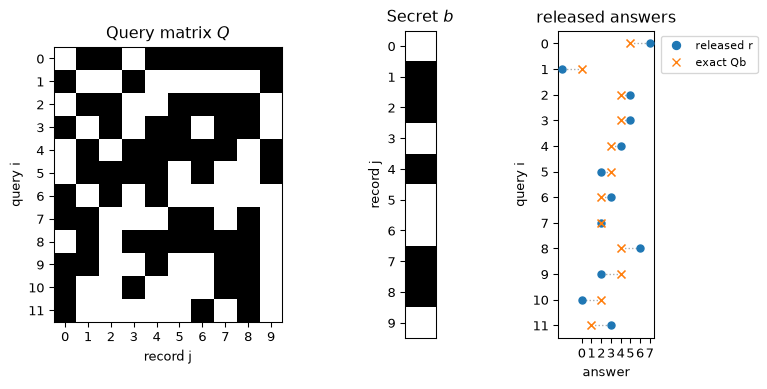

In [6]:
# Reconstruct the three ingredients from the uniform-noise mechanism:
# the (queries x records) matrix Q, the secret column b, and the answers.
np.random.seed(SEED)  # fix the injected noise
Q = baseline_mechanism.query_public_data(queries).T
b = baseline_mechanism.get_true_response_for_compression_only().to_numpy()
exact = baseline_mechanism.exact_query_for_compression_only(queries)
r = baseline_mechanism.noisy_query(queries, noise=2)

plot_query_matrix_overview(Q, b, r, exact=exact)

## Laplace-noise variant

Similarly, we can add noise that is sampled from the (integer) Laplace distribution, and achieve similar results.

In [7]:
laplace_noise = lambda noise, queries: np.round(np.random.laplace(0, noise, len(queries))).astype(int)
Laplace_mechanism = QueryMechanism(dataset, 'A', [], laplace_noise)
Laplace_mechanism.set_dataset(data_size)

## Laplace-noise visual view

The same visual view for the Laplace mechanism: the query matrix and the secret are unchanged, only the pattern of noise in the right panel differs.

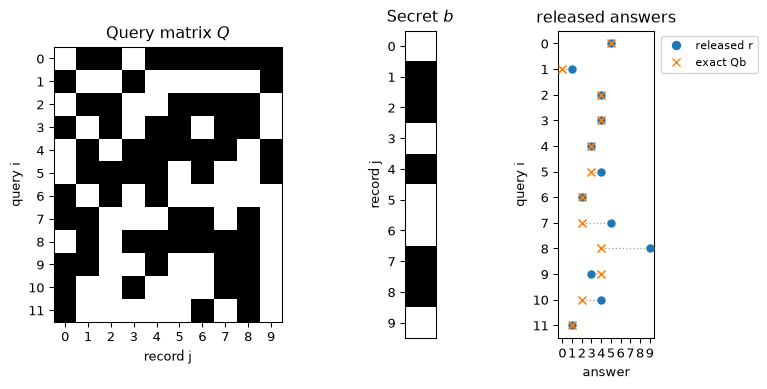

In [8]:
np.random.seed(SEED)  # fix the injected noise
Q = Laplace_mechanism.query_public_data(queries).T
b = Laplace_mechanism.get_true_response_for_compression_only().to_numpy()
exact = Laplace_mechanism.exact_query_for_compression_only(queries)
r = Laplace_mechanism.noisy_query(queries, noise=2)

plot_query_matrix_overview(Q, b, r, exact=exact)

## Step 3: solving the system

Finally, we must find an approximation $\hat{y}$ that minimizes some error measure of the difference $Q \cdot \hat{y} - r$. We will consider three methods to perform this minimization.

## Geometric interpretation {.smaller}

Before turning to algorithms, it pays to picture what the queries do geometrically. Think of the secret as a point in the cube $[0,1]^n$, whose corners are exactly the binary vectors. A single exact query $q_i^\top x = r_i$ is a hyperplane, and an *approximate* answer thickens that hyperplane into a **slab** $r_i - \alpha \le q_i^\top x \le r_i + \alpha$. Every query the attacker issues carves the cube with another slab, and the database must lie in the intersection of all of them. Reconstruction succeeds when these slabs intersect in a region so small that only one Boolean corner survives.

## One query in two dimensions

With two records the cube is the unit square. Pick a true corner (which fixes the released answer), then add queries to watch each exact line thicken into an accuracy slab, see its normal vector, and check which Boolean corners remain feasible.

<iframe src="apps/reconstruction-2d-slab/index.html" width="100%" height="640" style="border:0" loading="lazy" title="Interactive 2-D reconstruction slab explorer"></iframe>


## Slabs in three dimensions

With three records the database is one of the eight corners of the cube $[0,1]^3$. Choose a true corner, then toggle queries to see the planes thicken into slabs and watch the set of feasible corners shrink.

<iframe src="apps/reconstruction-3d-slabs/index.html" width="100%" height="660" style="border:0" loading="lazy" title="Interactive 3-D reconstruction slab explorer"></iframe>


## Option 1: brute force

This is the most straight forward method. Simply running over all possible binary vectors and finding the one that minimizes the $\ell_{\infty}$ error (over $m$ responses).

In [9]:
num_queries = 5 * data_size
noise_scale = int(data_size * 0.3)

# Seed the random queries and noise so this run is reproducible.
np.random.seed(SEED)
public_data = baseline_mechanism.get_public_data()
queries = [choose_random_subset(public_data) for _ in range(num_queries)]
subsets = baseline_mechanism.query_public_data(queries).T
responses = baseline_mechanism.noisy_query(queries, noise_scale)

In [10]:
from libdpy.attacks.reconstruction.reconstruction_attacks import get_mean_reconstruction_error
from libdpy.attacks.reconstruction.solvers import int_prog_reconstruction

# print the original vector as an array of values and the reconstructed vector
original_vector = baseline_mechanism.get_true_response_for_compression_only().to_numpy()
reconstructed_vector = int_prog_reconstruction(subsets, responses).T
reconstruction_error = get_mean_reconstruction_error(reconstructed_vector, original_vector) / data_size
print('Original vector:      ', original_vector)
print('Reconstructed vector: ', reconstructed_vector)
print('Reconstruction error = ', reconstruction_error)

Original vector:       [0 1 1 0 1 0 0 1 1 0]
Reconstructed vector:  [0 1 1 0 1 0 0 1 1 0]
Reconstruction error =  0.0


## Brute force scales poorly

But this quickly becomes very inefficient.

In [11]:
#| eval: false
data_size = 20
num_queries = 5 * data_size
noise_scale = int(data_size * 0.3)

# A larger fixed dataset to show the brute-force attack becoming infeasible.
secret_column_20 = [0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
dataset_20 = pd.DataFrame({'A': secret_column_20, 'B': np.ones(data_size)})
baseline_mechanism = QueryMechanism(dataset_20, 'A', [], uniform_noise)
baseline_mechanism.set_dataset(data_size)

np.random.seed(SEED)  # fix the random queries and noise inside the attack
original_vector = baseline_mechanism.get_true_response_for_compression_only().to_numpy()
reconstructed_vector = perform_reconstruction_attack_mechanizm(baseline_mechanism, int_prog_reconstruction, choose_random_subset, noise_scale, num_queries)
reconstruction_error = get_mean_reconstruction_error(reconstructed_vector, original_vector) / data_size

print('Original vector:      ', original_vector)
print('Reconstructed vector: ', reconstructed_vector)
print('Reconstruction error = ', reconstruction_error)

## Candidate elimination

Why does brute force work at all? Because the accuracy slabs eliminate almost every candidate. The plot below enumerates *all* $2^n$ Boolean databases for a small fixed instance ($n=12$, $m=22$) and places each one by its maximum $\ell_\infty$ residual (horizontal axis) against its Hamming distance from the true database (vertical axis). Candidates to the left of the accuracy bound $\alpha$ are **feasible** — consistent with every released answer. Only a handful survive, and they all sit close to the truth (small Hamming distance), which is exactly why returning any feasible candidate already reconstructs most bits correctly.

feasible candidates: 15 / 4096 (0.37%; 14 wrong + true b)


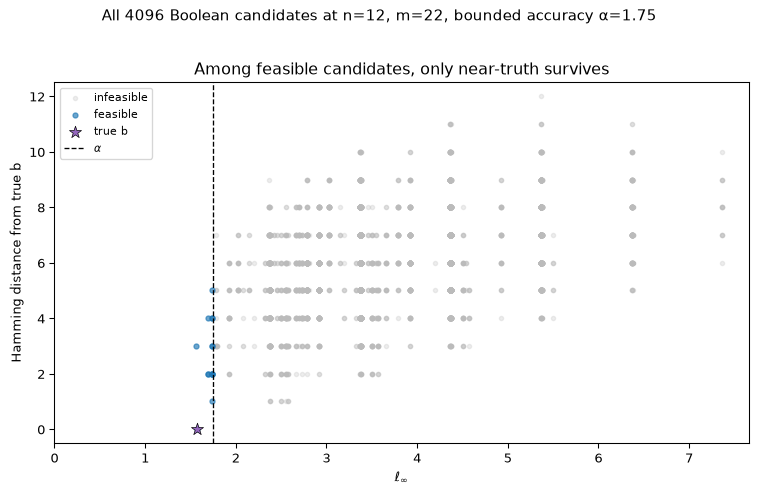

In [12]:
b_demo, Q_demo, r_demo, alpha_demo, demo_meta = make_candidate_elimination_demo(seed=2)
elim = compute_candidate_elimination(b_demo, Q_demo, r_demo, alpha_demo)

n_feasible = int(elim['feasible'].sum())
print(f"feasible candidates: {n_feasible} / {2 ** demo_meta['n']} "
      f"({100 * n_feasible / 2 ** demo_meta['n']:.2f}%; {n_feasible - 1} wrong + true b)")

plot_candidate_elimination_panels(
    elim['hamming_dist'],
    elim['max_residual'],
    elim['feasible'],
    alpha_demo,
    demo_meta['n'],
    m=demo_meta['m'],
    true_index=elim['true_index'],
)

## Option 2: linear regression

Replacing $\ell_{\infty}$ by $\ell_{2}$ this turns to a least squares problem, which can be solved using linear regression with the query matrix $Q$ and response vector $r$. 
However, since `linear regression` provides continuous values, and we need binary outcomes (indicating whether a sample has the sensitive attribute or not), we round the continuous results to the nearest binary value (0 or 1).

In [13]:
np.random.seed(SEED)  # same fixed instance as the brute-force example above
reconstructed_vector = perform_reconstruction_attack_mechanizm(baseline_mechanism, lin_reg_reconstruction, choose_random_subset, noise_scale, num_queries)
reconstruction_error = get_mean_reconstruction_error(reconstructed_vector, original_vector) / data_size

print('Original vector:      ', original_vector)
print('Reconstructed vector: ', reconstructed_vector)
print('Reconstruction error = ', reconstruction_error)

Original vector:       [0 1 1 0 1 0 0 1 1 0]
Reconstructed vector:  [0 0 0 0 0 1 1 1 1 0]
Reconstruction error =  0.05


## Scaling the heuristic

Now, we can easily scale up.

In [14]:
# Scale up: switch to a large, randomly generated dataset for the experiments.
full_data_size = 1000
full_dataset = pd.DataFrame({'A': np.random.binomial(1, 0.5, full_data_size), 'B': np.ones(full_data_size)})
baseline_mechanism = QueryMechanism(full_dataset, 'A', [], uniform_noise)

data_size = 100
num_queries = 5 * data_size
noise_scale = int(data_size * 0.05)
num_experiments = 1

reconstruction_error = compute_average_error_for_noise_scale(data_size, baseline_mechanism, num_experiments, lin_reg_reconstruction, choose_random_subset, noise_scale, num_queries)
print('Reconstruction error = ', reconstruction_error)

Reconstruction error =  0.06


## When least squares goes wrong {.smaller}

Linear regression minimizes the *squared* $\ell_2$ error, which makes it exquisitely sensitive to large residuals. A single answer that is far off — for instance a rare, large draw from a heavy-tailed noise distribution such as Laplace — gets squared, and the fit bends to accommodate that one outlier at the expense of every other coordinate. Such extreme values occur with low probability, but when they do they can corrupt the entire reconstruction.

There is a second, more fundamental problem, and it shows up even when *every* answer is accurate, as the next example demonstrates.

## OLS can leave the cube {.smaller}

Here the true database is $b = (1, 0, 0)$ and every released answer is within $\alpha = 0.2$ of the exact subset count. Because the query matrix is invertible, *unconstrained* least squares fits the released answers exactly and returns

$$x_{\mathrm{OLS}} = (1.2,\ 0.6,\ -0.4),$$

a point **outside** the valid domain $[0,1]^3$. Clipping it back to the cube gives $(1, 0.6, 0)$, which sits on the wrong side of the $x_2 = 1/2$ rounding threshold and therefore rounds to $(1, 1, 0)$ — an error.

The bounded-accuracy LP, by contrast, never leaves the cube: its feasible region is the segment $(1, s, 0)$ with $0 \le s \le 0.4$, every point of which rounds to the true $(1, 0, 0)$. In both panels, color encodes the method (red = OLS, blue = LP) and shape encodes the stage (circle = raw solution, square = clipped, diamond = rounded). The red path drops below the cube floor, is clipped back up, and rounds across the threshold to the wrong corner; the blue LP solution stays inside and rounds correctly.

This is exactly the gap that motivates the linear program below: by constraining the solution to $[0,1]^n$ and minimizing the $\ell_1$ error, it respects both the geometry of the cube and the accuracy slabs.

## OLS vs. LP geometry

The figure below separates the OLS path that leaves the cube from the bounded LP feasible segment.

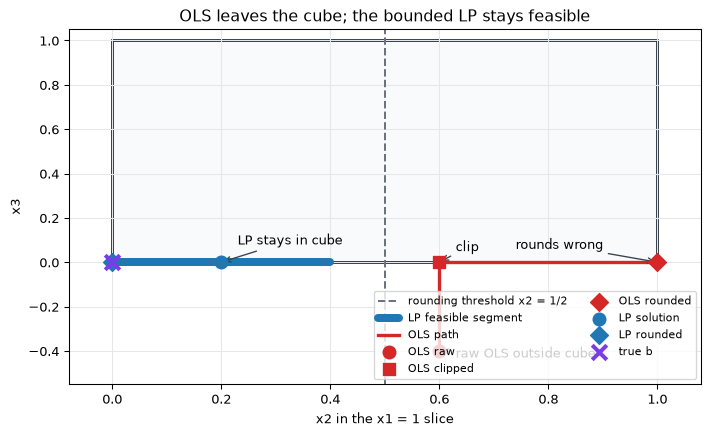

In [15]:
# Static Matplotlib replacement for the former browser 3-D figure.
# Work in the x1 = 1 slice; horizontal is x2 and vertical is x3.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.set_title("OLS leaves the cube; the bounded LP stays feasible")

cube = plt.Rectangle((0, 0), 1, 1, facecolor="#f8fafc", edgecolor="#111827", linewidth=2)
ax.add_patch(cube)
ax.axvline(0.5, color="#6b7280", linestyle="--", linewidth=1.5, label="rounding threshold x2 = 1/2")

ols_raw = np.array([0.6, -0.4])
ols_clipped = np.array([0.6, 0.0])
ols_rounded = np.array([1.0, 0.0])
lp_segment = np.array([[0.0, 0.0], [0.4, 0.0]])
lp_solution = np.array([0.2, 0.0])
lp_rounded = np.array([0.0, 0.0])
true_b = np.array([0.0, 0.0])

ax.plot(lp_segment[:, 0], lp_segment[:, 1], color="#1f77b4", linewidth=6, solid_capstyle="round", label="LP feasible segment")
ax.plot([ols_raw[0], ols_clipped[0], ols_rounded[0]], [ols_raw[1], ols_clipped[1], ols_rounded[1]], color="#d62728", linewidth=2.5, label="OLS path")
ax.scatter(*ols_raw, color="#d62728", s=90, marker="o", zorder=5, label="OLS raw")
ax.scatter(*ols_clipped, color="#d62728", s=90, marker="s", zorder=5, label="OLS clipped")
ax.scatter(*ols_rounded, color="#d62728", s=90, marker="D", zorder=5, label="OLS rounded")
ax.scatter(*lp_solution, color="#1f77b4", s=90, marker="o", zorder=5, label="LP solution")
ax.scatter(*lp_rounded, color="#1f77b4", s=90, marker="D", zorder=5, label="LP rounded")
ax.scatter(*true_b, color="#7c3aed", s=120, marker="x", linewidths=3, zorder=6, label="true b")

for point, text, offset in [
    (ols_raw, "raw OLS outside cube", (0.03, -0.03)),
    (ols_clipped, "clip", (0.03, 0.05)),
    (ols_rounded, "rounds wrong", (-0.26, 0.06)),
    (lp_solution, "LP stays in cube", (0.03, 0.08)),
]:
    ax.annotate(text, xy=point, xytext=point + np.array(offset), fontsize=10,
                arrowprops={"arrowstyle": "->", "linewidth": 1, "color": "#374151"})

ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-0.55, 1.05)
ax.set_xlabel("x2 in the x1 = 1 slice")
ax.set_ylabel("x3")
ax.grid(True, color="#e5e7eb", linewidth=0.8)
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=True)
plt.show()


## Option 3: linear programming {.smaller}
Moving to $\ell_{1}$ opens a third option, formalizing it as a linear programming problems of the following form:

$~~~~~~~~~~~~~~~~~~~~ \underset{e \in \mathbb{R}^{m}}{\min} \left(\sum_{i \in [m]} e_{i} \right)$

subject to $\forall i \in [n]$: $~~y_{i} \in [0, 1]$

$~~~~~~~~~~~~~~~~ \forall i \in [m]$: $\left<q_{i}, \hat{y} \right> - r_{i} \le e_{i}$

$~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ r_{i} - \left<q_{i}, \hat{y} \right> \le e_{i}$


In [16]:
reconstruction_error = compute_average_error_for_noise_scale(data_size, baseline_mechanism, num_experiments, lin_prog_reconstruction, choose_random_subset, noise_scale, num_queries)
print('Reconstruction error = ', reconstruction_error)

Reconstruction error =  0.17


## Summary {.smaller}

We have seen three ways to solve the reconstruction system, each replacing the error metric with a different norm and trading efficiency against guarantees:

| Method | Error metric | Cost | Guarantee |
| --- | --- | --- | --- |
| Brute force (integer programming) | $\ell_\infty$ | exponential in $n$ | exact, but infeasible beyond small $n$ |
| Linear regression | $\ell_2$ | polynomial | fast, but no success guarantee (and can leave the cube) |
| Linear programming | $\ell_1$ | polynomial | provably reconstructs when the noise is small enough |

To wrap up, we compare the two *efficient* attacks on a larger database ($n=100$): we sweep the noise scale the mechanism adds and, for each level, average the per-coordinate reconstruction error over several repetitions. This ties the lecture together — it quantifies how reconstruction degrades as more noise is injected, i.e. how much noise a mechanism needs in order to protect privacy.

## Noise is the defense -- at a cost

Finally, sweep the noise scale and compare the two efficient reconstruction attacks.

In [17]:
data_size = 100
num_queries = 5 * data_size
num_experiments = 1
noise_range = range(0, 21, 2)

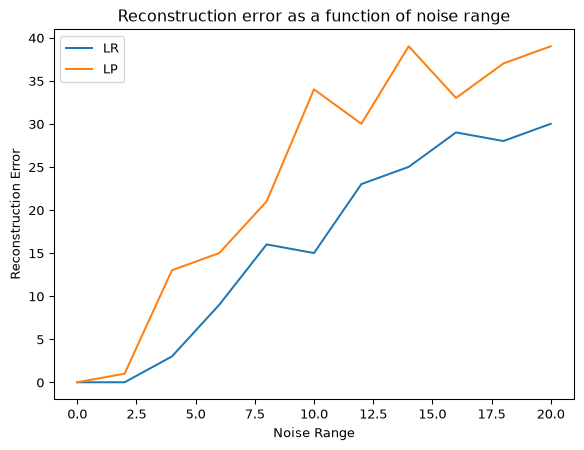

In [18]:
# The 2D slab widget above switches matplotlib to the Agg backend; restore inline rendering.
%matplotlib inline

rand_lr_error_arr = run_simulation(data_size, baseline_mechanism, num_experiments, lin_reg_reconstruction, choose_random_subset, noise_range, num_queries)
rand_lp_error_arr = run_simulation(data_size, baseline_mechanism, num_experiments, lin_prog_reconstruction,choose_random_subset, noise_range, num_queries)

errors = [(rand_lr_error_arr, "LR"), (rand_lp_error_arr, "LP")]
plot_reconstruction_error_as_noise_function(errors, noise_range)

## Reading the curve {.smaller}

**Reading the plot.** The horizontal axis is the noise scale added by the mechanism; the vertical axis is the average reconstruction error (the percentage of bits recovered incorrectly, so $0$ means perfect recovery and $\sim 50$ is no better than a random guess). At zero noise both attacks reconstruct the database almost perfectly. As the noise grows the error of both methods climbs steadily: larger noise widens the accuracy slabs, so more coordinates are left undetermined and more bits are guessed wrong. The two efficient attacks perform comparably here — recall that the linear program is the one carrying a provable guarantee in the small-noise regime, while linear regression is only a heuristic.

The shape of these curves *is* the privacy statement: reconstruction succeeds precisely when the noise is small, so the only way to defend against these attacks is to add enough noise — exactly the trade-off that differential privacy makes formal.